<a href='https://colab.research.google.com/github/fralfaro/ics294-latex/blob/main/colab/regresion_wage_inferencia.ipynb' target='_parent'><img src='https://colab.research.google.com/assets/colab-badge.svg' alt='Open In Colab'/></a>

# Regresión salarial e inferencia en R

Este notebook presenta un flujo completo de análisis para el dataset `wage1` del paquete `wooldridge`. La estructura sigue una exploración similar a `info()`, `isna().sum()`, `duplicated()` y `describe()` de Python, y luego conecta la descripción de los datos con la regresión lineal y los tests de hipótesis.

La variable dependiente será `lwage`, el logaritmo del salario por hora.

> Ejecuta el notebook en Google Colab seleccionando **Runtime > Change runtime type > R**.

## Objetivos

1. Conocer la estructura de la base: dimensiones, tipos, valores nulos, duplicados y estadística descriptiva.
2. Visualizar distribuciones univariadas y relaciones bivariadas.
3. Estimar y comparar modelos con una, dos y tres variables explicativas.
4. Construir intervalos de confianza y realizar tests individuales, de diferencias y conjuntos.
5. Revisar gráficamente la calidad del ajuste y sus residuos.

En este material usaremos **modelo con una explicativa** para `lwage ~ educ` y **modelo con dos explicativas** para `lwage ~ educ + exper`. En algunos cursos a este último se le llama regresión bivariada; lo importante es indicar siempre la fórmula del modelo.

## 1. Preparación y paquetes

`wooldridge` contiene los datos, `dplyr` organiza las tablas, `ggplot2` produce los gráficos, `lmtest` muestra tests de coeficientes, `sandwich` calcula errores estándar robustos y `car` permite probar restricciones lineales con `linearHypothesis()`. La instalación de `car` puede tardar porque requiere varias dependencias adicionales.

In [1]:
paquetes <- c('wooldridge', 'dplyr', 'ggplot2', 'lmtest', 'sandwich', 'car')

instalar <- paquetes[!vapply(paquetes, requireNamespace, logical(1), quietly = TRUE)]
if (length(instalar) > 0) {
  install.packages(instalar, repos = 'https://cloud.r-project.org')
}

invisible(lapply(paquetes, library, character.only = TRUE))
theme_set(theme_minimal(base_size = 12))
options(width = 110)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘forecast’, ‘doBy’, ‘pbkrtest’, ‘lme4’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




## 2. Carga y preparación de la base

`wage1` contiene 526 observaciones y variables laborales, demográficas y geográficas. Para que el análisis sea transparente, primero conservamos una copia del dataset original y luego trabajamos con un `tibble`.

In [2]:
data('wage1', package = 'wooldridge')
wage_df <- as_tibble(wage1)

# Comprobamos que las variables principales existan y construimos lwage si fuera necesario.
if (!'lwage' %in% names(wage_df)) {
  wage_df <- wage_df %>% mutate(lwage = log(wage))
}

cat('Filas:', nrow(wage_df), '| Columnas:', ncol(wage_df), '\n')
head(wage_df, 8)

Filas: 526 | Columnas: 24 


wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,⋯,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>
3.10,11,2,0,0,1,0,2,1,0,⋯,0,0,0,0,0,0,0,1.131402,4,0
3.24,12,22,2,0,1,1,3,1,0,⋯,0,0,1,0,0,0,1,1.175573,484,4
3.00,11,2,0,0,0,0,2,0,0,⋯,0,1,0,0,0,0,0,1.098612,4,0
6.00,8,44,28,0,0,1,0,1,0,⋯,0,0,0,0,0,1,0,1.791759,1936,784
5.30,12,7,2,0,0,1,1,0,0,⋯,0,0,0,0,0,0,0,1.667707,49,4
8.75,16,9,8,0,0,1,0,1,0,⋯,0,0,0,1,1,0,0,2.169054,81,64
11.25,18,15,7,0,0,0,0,1,0,⋯,0,1,0,0,1,0,0,2.420368,225,49
5.00,12,5,3,0,1,0,0,1,0,⋯,0,0,0,0,1,0,0,1.609438,25,9


## 3. Exploración tipo `info()` de Python

La siguiente tabla resume el nombre de cada variable, su clase en R, el número de observaciones válidas, los valores nulos y la cantidad de valores distintos. En R, `integer` y `numeric` son tipos numéricos; las variables 0/1 del dataset están almacenadas como números enteros.

In [3]:
tabla_estructura <- tibble(
  variable = names(wage_df),
  tipo = vapply(wage_df, function(x) paste(class(x), collapse = ', '), character(1)),
  observaciones = nrow(wage_df),
  no_nulos = vapply(wage_df, function(x) sum(!is.na(x)), integer(1)),
  nulos = vapply(wage_df, function(x) sum(is.na(x)), integer(1)),
  porcentaje_nulos = round(100 * nulos / observaciones, 2),
  valores_unicos = vapply(wage_df, function(x) dplyr::n_distinct(x, na.rm = FALSE), integer(1))
)

tabla_estructura

variable,tipo,observaciones,no_nulos,nulos,porcentaje_nulos,valores_unicos
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>
wage,numeric,526,526,0,0,241
educ,integer,526,526,0,0,18
exper,integer,526,526,0,0,51
tenure,integer,526,526,0,0,34
nonwhite,integer,526,526,0,0,2
female,integer,526,526,0,0,2
married,integer,526,526,0,0,2
numdep,integer,526,526,0,0,7
smsa,integer,526,526,0,0,2


### Valores nulos y datos duplicados

No basta con mirar el total de `NA`: también conviene revisar si existen filas repetidas. En este dataset esperamos una base completa y sin duplicados, pero el código queda listo para cualquier base similar.

In [4]:
resumen_calidad <- tibble(
  filas = nrow(wage_df),
  columnas = ncol(wage_df),
  celdas_nulas = sum(is.na(wage_df)),
  filas_con_nulos = sum(!complete.cases(wage_df)),
  filas_duplicadas = sum(duplicated(wage_df))
)
resumen_calidad

# Si hubiera duplicados, esta instrucción mostraría los primeros diez.
if (resumen_calidad$filas_duplicadas > 0) {
  wage_df[duplicated(wage_df) | duplicated(wage_df, fromLast = TRUE), ] %>% head(10)
} else {
  cat('No se encontraron filas duplicadas.\n')
}

filas,columnas,celdas_nulas,filas_con_nulos,filas_duplicadas
<int>,<int>,<int>,<int>,<int>
526,24,0,0,0


No se encontraron filas duplicadas.


## 4. Estadística descriptiva tipo `describe()`

Para las variables numéricas calculamos tamaño muestral, faltantes, media, desviación estándar, mínimo, percentiles 25 y 75, mediana y máximo. Los percentiles permiten ver la dispersión sin depender únicamente de la media.

In [5]:
variables_numericas <- names(wage_df)[vapply(wage_df, is.numeric, logical(1))]

describir_variable <- function(nombre) {
  x <- wage_df[[nombre]]
  tibble(
    variable = nombre,
    n = sum(!is.na(x)),
    nulos = sum(is.na(x)),
    media = mean(x, na.rm = TRUE),
    desviacion = sd(x, na.rm = TRUE),
    minimo = min(x, na.rm = TRUE),
    p25 = as.numeric(quantile(x, 0.25, na.rm = TRUE)),
    mediana = median(x, na.rm = TRUE),
    p75 = as.numeric(quantile(x, 0.75, na.rm = TRUE)),
    maximo = max(x, na.rm = TRUE)
  )
}

estadisticas_descriptivas <- bind_rows(lapply(variables_numericas, describir_variable)) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))
estadisticas_descriptivas

variable,n,nulos,media,desviacion,minimo,p25,mediana,p75,maximo
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
wage,526,0,5.896,3.693,0.530,3.330,4.650,6.880,24.980
educ,526,0,12.563,2.769,0.000,12.000,12.000,14.000,18.000
exper,526,0,17.017,13.572,1.000,5.000,13.500,26.000,51.000
tenure,526,0,5.105,7.224,0.000,0.000,2.000,7.000,44.000
nonwhite,526,0,0.103,0.304,0.000,0.000,0.000,0.000,1.000
female,526,0,0.479,0.500,0.000,0.000,0.000,1.000,1.000
married,526,0,0.608,0.489,0.000,0.000,1.000,1.000,1.000
numdep,526,0,1.044,1.262,0.000,0.000,1.000,2.000,6.000
smsa,526,0,0.722,0.448,0.000,0.000,1.000,1.000,1.000


### Frecuencias de variables binarias

Las variables `female`, `married` y `nonwhite` son indicadores 0/1. Para ellas es más informativo mostrar frecuencias y porcentajes que una media aislada.

In [6]:
variables_binarias <- c('female', 'married', 'nonwhite')

frecuencias_binarias <- bind_rows(lapply(variables_binarias, function(nombre) {
  wage_df %>%
    count(valor = .data[[nombre]], name = 'frecuencia') %>%
    mutate(variable = nombre, porcentaje = round(100 * frecuencia / sum(frecuencia), 2)) %>%
    select(variable, valor, frecuencia, porcentaje)
}))
frecuencias_binarias

variable,valor,frecuencia,porcentaje
<chr>,<int>,<int>,<dbl>
female,0,274,52.09
female,1,252,47.91
married,0,206,39.16
married,1,320,60.84
nonwhite,0,472,89.73
nonwhite,1,54,10.27


## 5. Gráficos univariados

Los histogramas muestran la forma de las distribuciones y los boxplots ayudan a detectar valores extremos. El salario suele ser asimétrico hacia la derecha; por eso también observamos `lwage = log(wage)`.

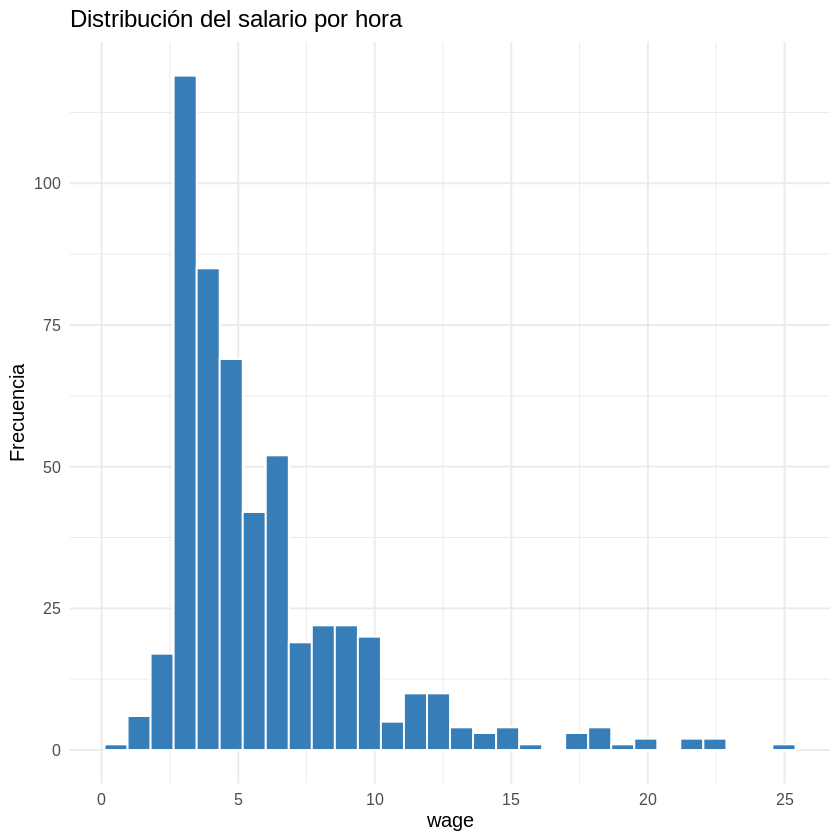

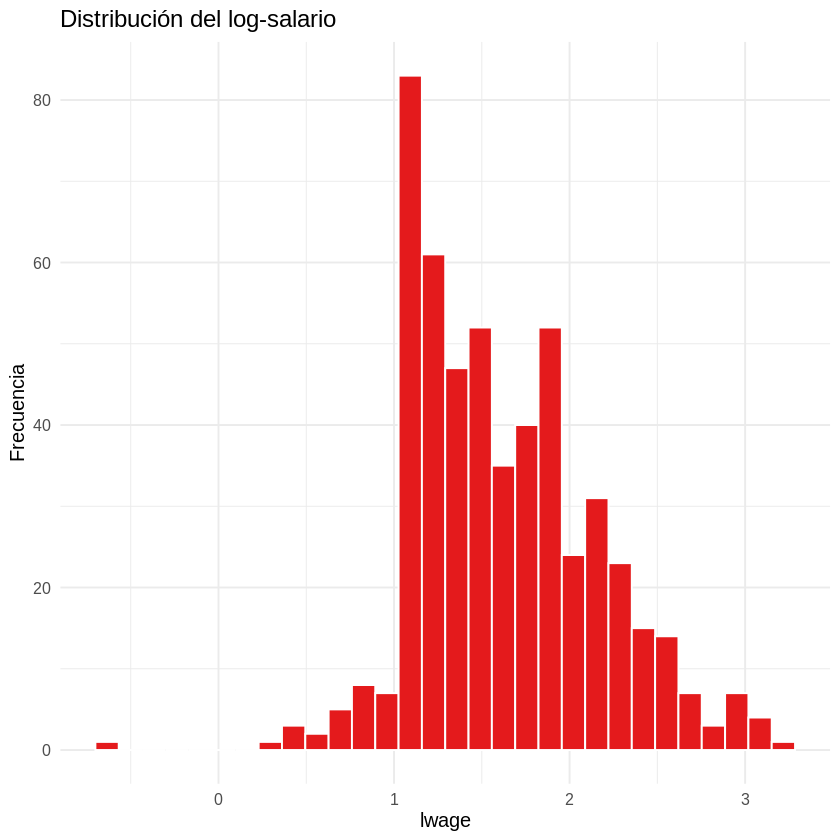

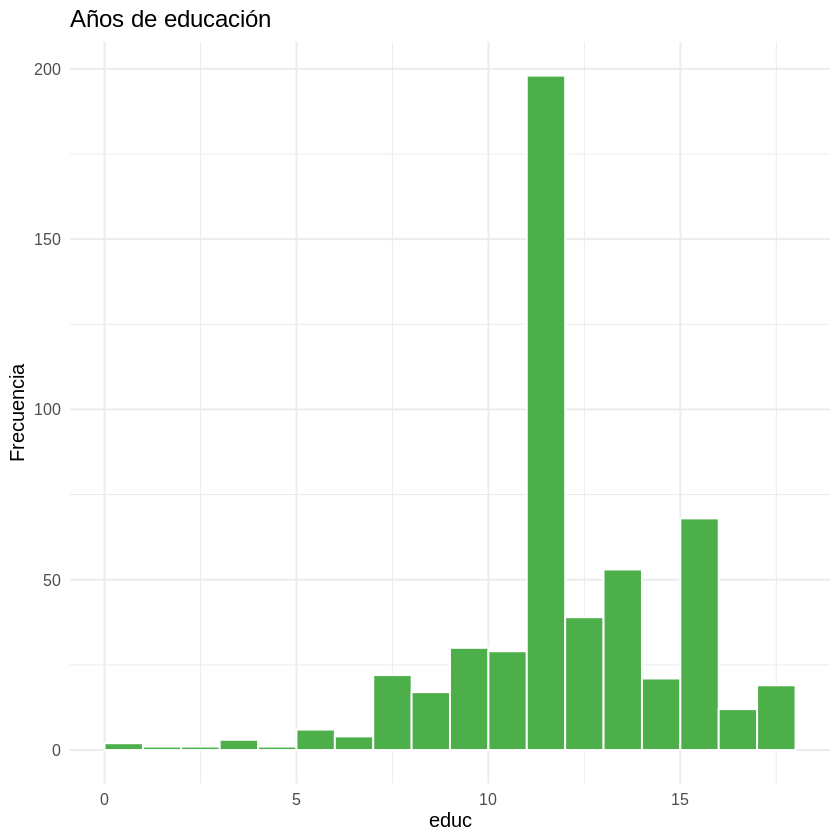

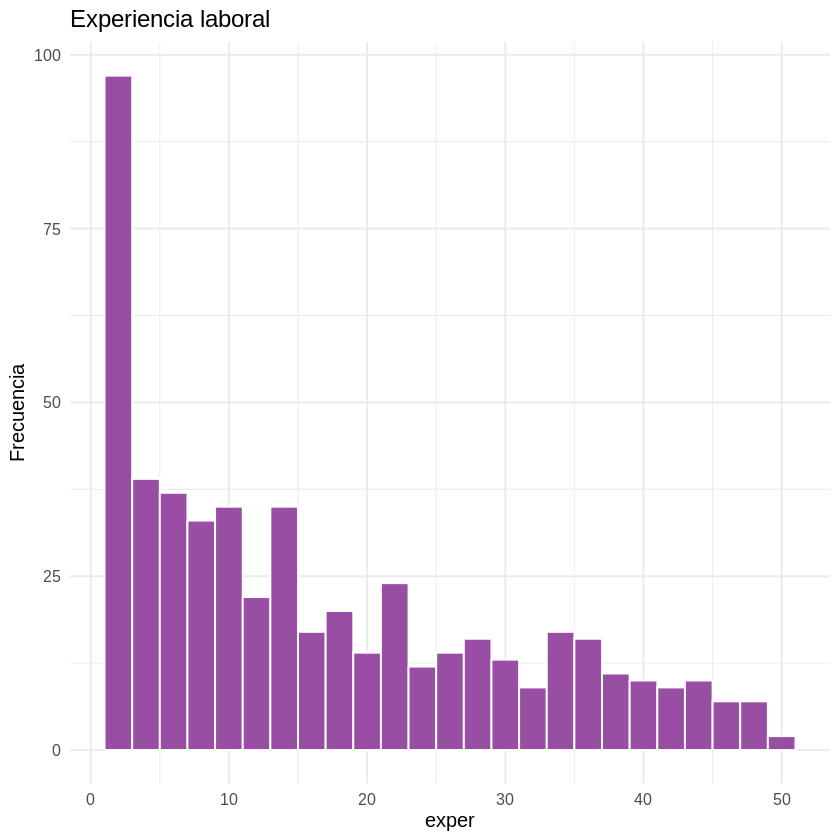

In [7]:
p_wage <- ggplot(wage_df, aes(wage)) +
  geom_histogram(bins = 30, fill = '#377eb8', color = 'white') +
  labs(title = 'Distribución del salario por hora', x = 'wage', y = 'Frecuencia')

p_lwage <- ggplot(wage_df, aes(lwage)) +
  geom_histogram(bins = 30, fill = '#e41a1c', color = 'white') +
  labs(title = 'Distribución del log-salario', x = 'lwage', y = 'Frecuencia')

p_educ <- ggplot(wage_df, aes(educ)) +
  geom_histogram(binwidth = 1, boundary = 0, fill = '#4daf4a', color = 'white') +
  labs(title = 'Años de educación', x = 'educ', y = 'Frecuencia')

p_exper <- ggplot(wage_df, aes(exper)) +
  geom_histogram(binwidth = 2, fill = '#984ea3', color = 'white') +
  labs(title = 'Experiencia laboral', x = 'exper', y = 'Frecuencia')

print(p_wage)
print(p_lwage)
print(p_educ)
print(p_exper)

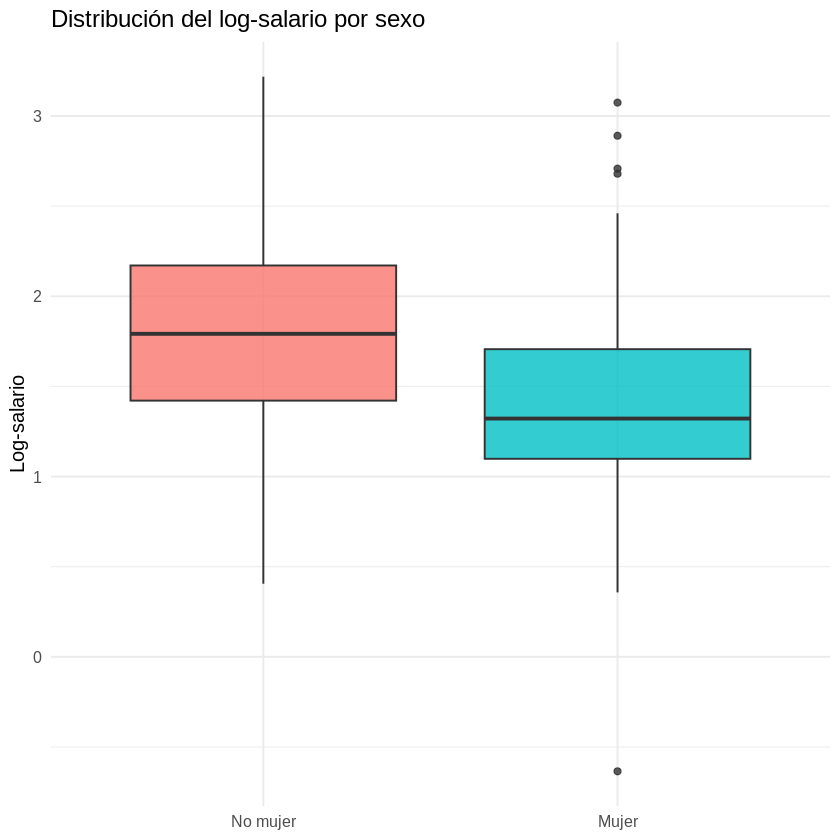

In [8]:
ggplot(wage_df, aes(x = factor(female), y = lwage, fill = factor(female))) +
  geom_boxplot(alpha = 0.8, show.legend = FALSE) +
  scale_x_discrete(labels = c('0' = 'No mujer', '1' = 'Mujer')) +
  labs(title = 'Distribución del log-salario por sexo', x = NULL, y = 'Log-salario')

## 6. Gráficos bivariados

Ahora estudiamos relaciones entre dos variables. La línea roja es un ajuste lineal descriptivo; no debe interpretarse automáticamente como un efecto causal. El color permite comparar visualmente los grupos definidos por `female`.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


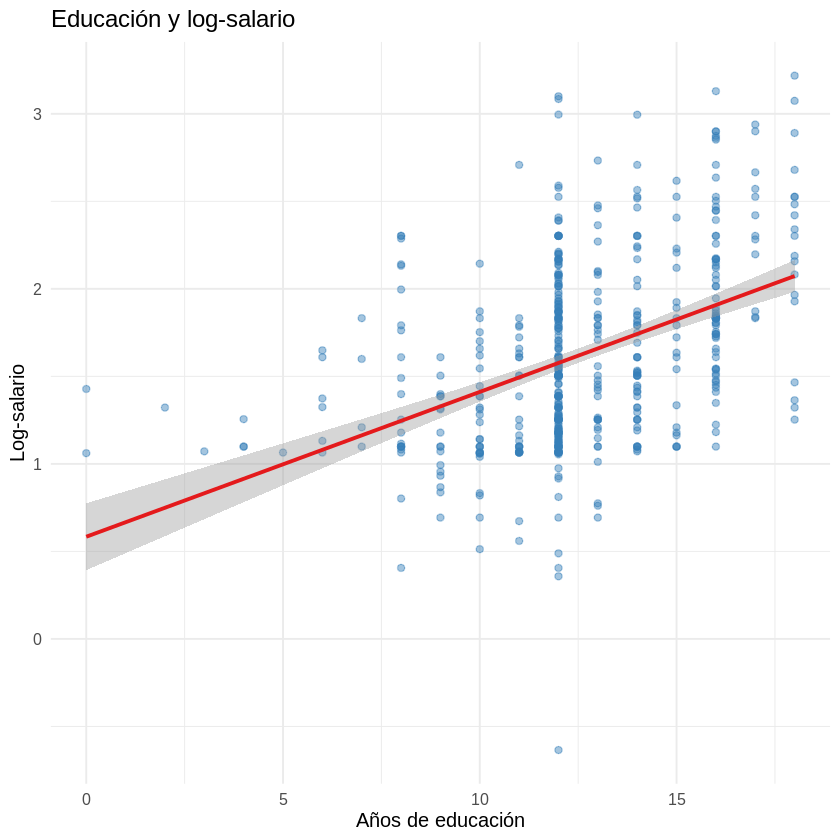

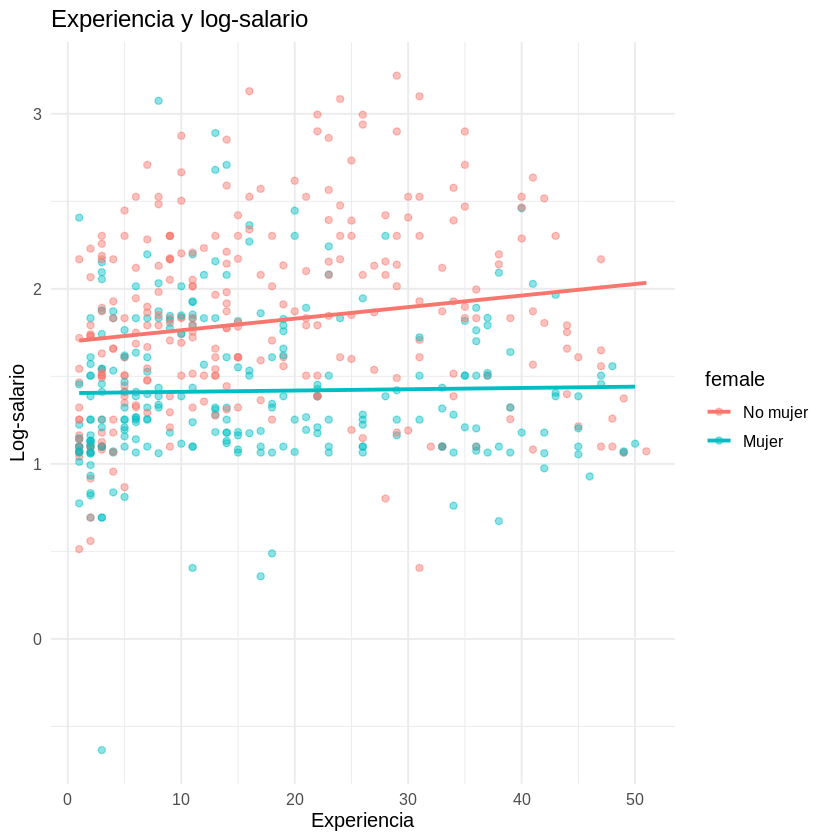

In [9]:
p_educ_lwage <- ggplot(wage_df, aes(x = educ, y = lwage)) +
  geom_point(alpha = 0.45, color = '#377eb8') +
  geom_smooth(method = 'lm', se = TRUE, color = '#e41a1c') +
  labs(title = 'Educación y log-salario', x = 'Años de educación', y = 'Log-salario')

p_exper_lwage <- ggplot(wage_df, aes(x = exper, y = lwage, color = factor(female))) +
  geom_point(alpha = 0.45) +
  geom_smooth(method = 'lm', se = FALSE) +
  scale_color_discrete(name = 'female', labels = c('0' = 'No mujer', '1' = 'Mujer')) +
  labs(title = 'Experiencia y log-salario', x = 'Experiencia', y = 'Log-salario')

print(p_educ_lwage)
print(p_exper_lwage)

,wage,lwage,educ,exper,tenure
wage,1.000,0.937,0.406,0.113,0.347
lwage,0.937,1.000,0.431,0.111,0.326
educ,0.406,0.431,1.000,-0.300,-0.056
exper,0.113,0.111,-0.300,1.000,0.499
tenure,0.347,0.326,-0.056,0.499,1.000


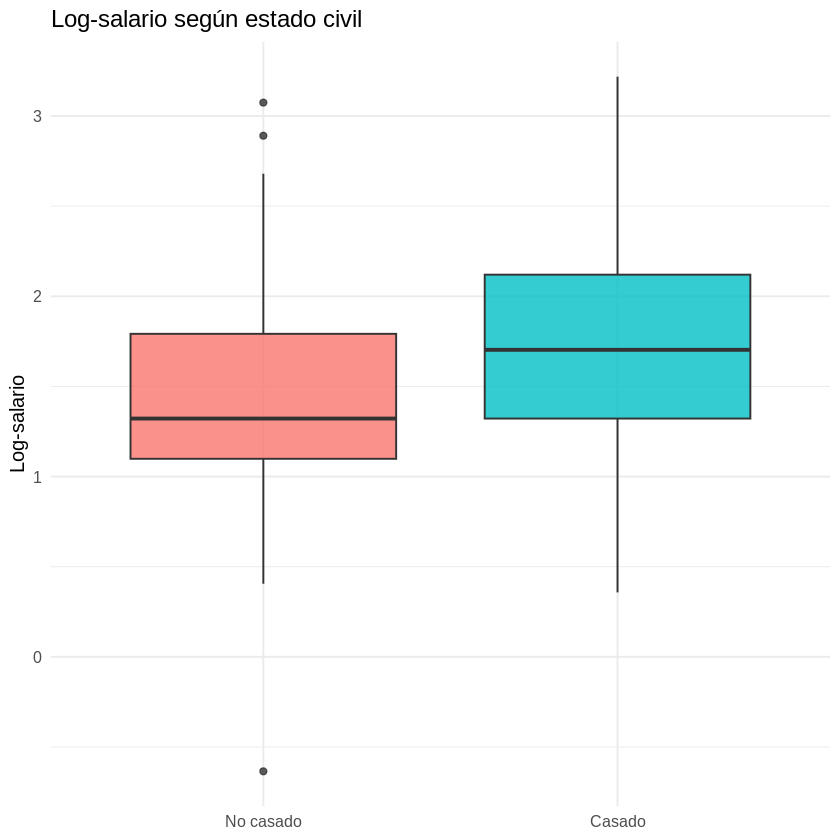

In [10]:
ggplot(wage_df, aes(x = factor(married), y = lwage, fill = factor(married))) +
  geom_boxplot(alpha = 0.8, show.legend = FALSE) +
  scale_x_discrete(labels = c('0' = 'No casado', '1' = 'Casado')) +
  labs(title = 'Log-salario según estado civil', x = NULL, y = 'Log-salario')

# Correlaciones entre las variables continuas principales.
wage_df %>%
  select(wage, lwage, educ, exper, tenure) %>%
  cor(use = 'complete.obs') %>%
  round(3)

## 7. Ajuste de regresiones

Estimaremos tres modelos para ver qué cambia al incorporar variables: 

- **Una explicativa:** `lwage ~ educ`.
- **Dos explicativas:** `lwage ~ educ + exper`.
- **Modelo ampliado:** `lwage ~ educ + exper + tenure`.

En los tres casos `lm()` estima por mínimos cuadrados ordinarios. Los coeficientes miden asociaciones parciales cuando hay más de una variable explicativa.

In [11]:
modelo_uni <- lm(lwage ~ educ, data = wage_df)
modelo_bi <- lm(lwage ~ educ + exper, data = wage_df)
modelo_multi <- lm(lwage ~ educ + exper + tenure, data = wage_df)

summary(modelo_uni)
summary(modelo_bi)
summary(modelo_multi)


Call:
lm(formula = lwage ~ educ, data = wage_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.21158 -0.36393 -0.07263  0.29712  1.52339 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.583773   0.097336   5.998 3.74e-09 ***
educ        0.082744   0.007567  10.935  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4801 on 524 degrees of freedom
Multiple R-squared:  0.1858,	Adjusted R-squared:  0.1843 
F-statistic: 119.6 on 1 and 524 DF,  p-value: < 2.2e-16



Call:
lm(formula = lwage ~ educ + exper, data = wage_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05800 -0.30136 -0.04539  0.30601  1.44425 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.216854   0.108595   1.997   0.0464 *  
educ        0.097936   0.007622  12.848  < 2e-16 ***
exper       0.010347   0.001555   6.653 7.24e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4614 on 523 degrees of freedom
Multiple R-squared:  0.2493,	Adjusted R-squared:  0.2465 
F-statistic: 86.86 on 2 and 523 DF,  p-value: < 2.2e-16



Call:
lm(formula = lwage ~ educ + exper + tenure, data = wage_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05802 -0.29645 -0.03265  0.28788  1.42809 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.284360   0.104190   2.729  0.00656 ** 
educ        0.092029   0.007330  12.555  < 2e-16 ***
exper       0.004121   0.001723   2.391  0.01714 *  
tenure      0.022067   0.003094   7.133 3.29e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4409 on 522 degrees of freedom
Multiple R-squared:  0.316,	Adjusted R-squared:  0.3121 
F-statistic: 80.39 on 3 and 522 DF,  p-value: < 2.2e-16


### Comparación del ajuste

`R2` indica la proporción de variación de `lwage` explicada por el modelo dentro de esta muestra. `R2 ajustado` penaliza por agregar variables. El RMSE resume el tamaño típico de los residuos en unidades de log-salario. Ninguna de estas medidas, por sí sola, demuestra causalidad ni garantiza que el modelo sea correcto.

In [12]:
resumen_ajuste <- function(mod, nombre) {
  s <- summary(mod)
  tibble(
    modelo = nombre,
    n = length(resid(mod)),
    r2 = s$r.squared,
    r2_ajustado = s$adj.r.squared,
    rmse = s$sigma,
    estadistico_f = unname(s$fstatistic['value']),
    gl_numerador = unname(s$fstatistic['numdf']),
    gl_denominador = unname(s$fstatistic['dendf'])
  )
}

tabla_ajuste <- bind_rows(
  resumen_ajuste(modelo_uni, 'Una explicativa: lwage ~ educ'),
  resumen_ajuste(modelo_bi, 'Dos explicativas: lwage ~ educ + exper'),
  resumen_ajuste(modelo_multi, 'Ampliado: lwage ~ educ + exper + tenure')
) %>% mutate(across(where(is.numeric), ~ round(.x, 4)))
tabla_ajuste

modelo,n,r2,r2_ajustado,rmse,estadistico_f,gl_numerador,gl_denominador
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Una explicativa: lwage ~ educ,526,0.1858,0.1843,0.4801,119.5816,1,524
Dos explicativas: lwage ~ educ + exper,526,0.2493,0.2465,0.4614,86.8617,2,523
Ampliado: lwage ~ educ + exper + tenure,526,0.3160,0.3121,0.4409,80.3909,3,522


### Visualización del ajuste

En el modelo con una explicativa podemos dibujar directamente la recta estimada. Para el modelo ampliado usamos un gráfico de valores observados contra valores ajustados: cuanto más cerca estén los puntos de la diagonal, mejor reproduce el modelo los valores observados en la muestra.

`geom_smooth()` using formula = 'y ~ x'


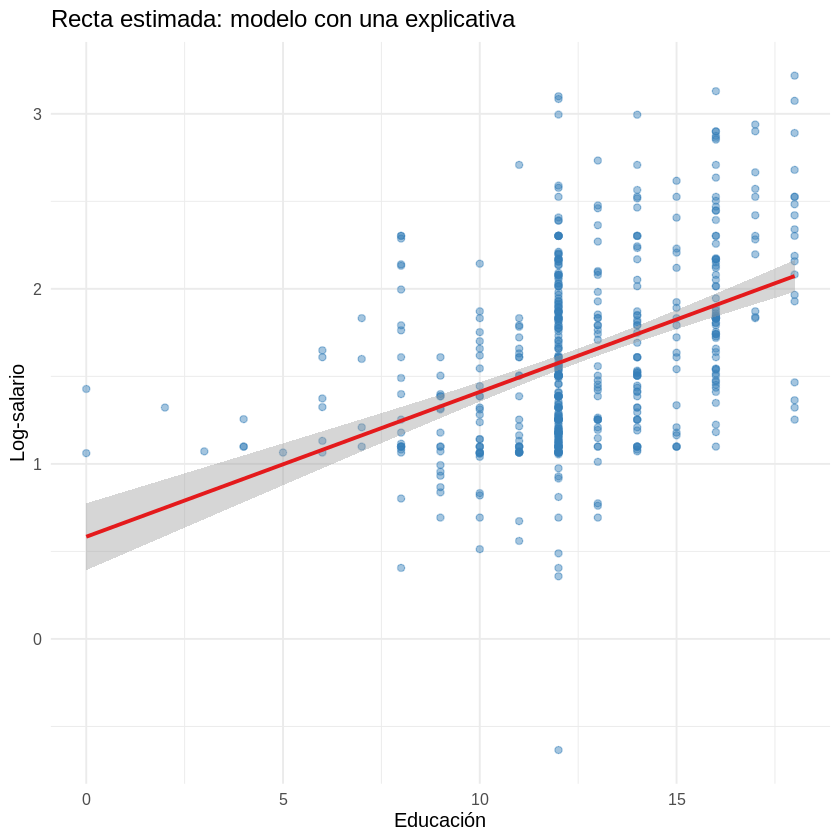

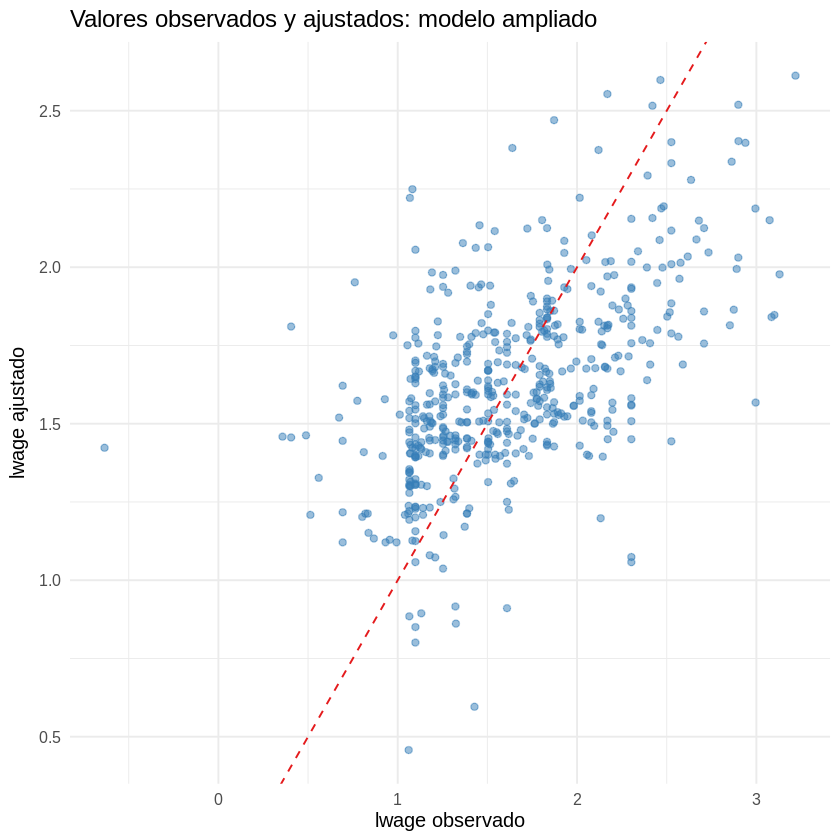

In [13]:
ggplot(wage_df, aes(x = educ, y = lwage)) +
  geom_point(alpha = 0.45, color = '#377eb8') +
  geom_smooth(method = 'lm', se = TRUE, color = '#e41a1c') +
  labs(title = 'Recta estimada: modelo con una explicativa', x = 'Educación', y = 'Log-salario')

observado_ajustado <- tibble(
  observado = wage_df$lwage,
  ajustado = fitted(modelo_multi)
)

ggplot(observado_ajustado, aes(x = observado, y = ajustado)) +
  geom_point(alpha = 0.5, color = '#377eb8') +
  geom_abline(slope = 1, intercept = 0, linetype = 'dashed', color = '#e41a1c') +
  labs(title = 'Valores observados y ajustados: modelo ampliado', x = 'lwage observado', y = 'lwage ajustado')

## 8. Coeficientes e intervalos de confianza

Como `lwage` está en logaritmos y las explicativas están en niveles, un coeficiente `beta` se interpreta aproximadamente como `100 * beta` por ciento ante un aumento de una unidad en la explicativa. La transformación exacta es `100 * (exp(beta) - 1)` por ciento.

In [14]:
ic <- confint(modelo_multi, level = 0.95)
coeficientes <- tibble(
  parametro = names(coef(modelo_multi)),
  beta = as.numeric(coef(modelo_multi)),
  limite_inferior = ic[, 1],
  limite_superior = ic[, 2]
) %>%
  mutate(
    efecto_aprox_porcentaje = 100 * beta,
    efecto_exacto_porcentaje = 100 * (exp(beta) - 1)
  )
coeficientes

parametro,beta,limite_inferior,limite_superior,efecto_aprox_porcentaje,efecto_exacto_porcentaje
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.284359541,0.0796755675,0.48904351,28.4359541,32.8910643
educ,0.092028988,0.0776292151,0.10642876,9.2028988,9.6396604
exper,0.004121109,0.0007356984,0.00750652,0.4121109,0.4129613
tenure,0.022067218,0.0159896854,0.02814475,2.2067218,2.2312500


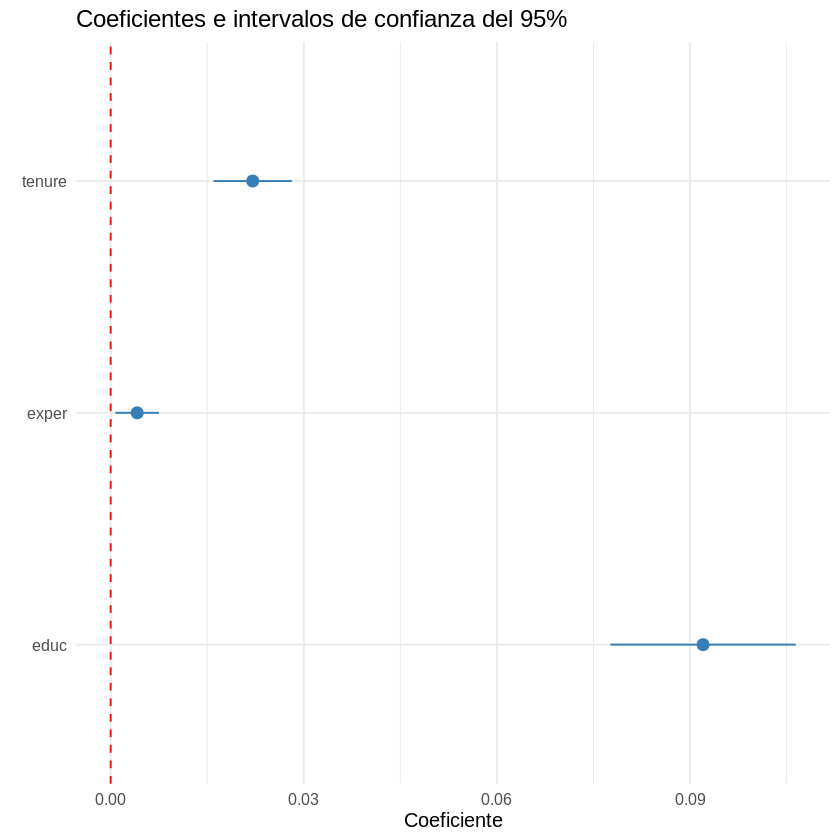

In [15]:
coeficientes %>%
  filter(parametro != '(Intercept)') %>%
  ggplot(aes(x = parametro, y = beta, ymin = limite_inferior, ymax = limite_superior)) +
  geom_pointrange(color = '#377eb8') +
  geom_hline(yintercept = 0, linetype = 'dashed', color = '#e41a1c') +
  coord_flip() +
  labs(title = 'Coeficientes e intervalos de confianza del 95%', x = NULL, y = 'Coeficiente')

## 9. Tipos de hipótesis sobre los parámetros

Una hipótesis nula `H0` es una afirmación concreta sobre los parámetros poblacionales. La decisión usual se toma con un nivel de significancia `alpha = 0.05`: 

- **Individual:** `H0: beta_j = 0`. Se usa un test t para un coeficiente.
- **Diferencia:** `H0: beta_educ - beta_exper = 0`. Se prueba una restricción lineal.
- **Conjunta:** `H0: beta_exper = 0` y `beta_tenure = 0`. Se usa un test F/Wald.
- **Intervalo:** si el intervalo de confianza al 95% no contiene el valor nulo, se rechaza la hipótesis bilateral al 5%.

Un `p-value < 0.05` es evidencia contra `H0`; no significa que la hipótesis alternativa sea demostrada con certeza ni que exista causalidad.

### 9.1 Hipótesis individual: un beta igual a cero

Para `exper`, la hipótesis es `H0: beta_exper = 0` contra `H1: beta_exper != 0`. `summary()` de `lm()` ya entrega este test; `coeftest()` muestra la misma tabla de forma explícita.

In [16]:
# Test t clásico, usando los errores estándar usuales de lm().
coeftest(modelo_multi)

# Intervalos de confianza de todos los coeficientes.
confint(modelo_multi, level = 0.95)


t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.2843595  0.1041904  2.7292  0.006562 ** 
educ        0.0920290  0.0073299 12.5552 < 2.2e-16 ***
exper       0.0041211  0.0017233  2.3914  0.017136 *  
tenure      0.0220672  0.0030936  7.1331 3.294e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


,2.5 %,97.5 %
(Intercept),0.0796755675,0.48904351
educ,0.0776292151,0.10642876
exper,0.0007356984,0.00750652
tenure,0.0159896854,0.02814475


### Errores estándar robustos

Si sospechamos heterocedasticidad, los coeficientes OLS no cambian, pero sí puede cambiar la incertidumbre estimada. `vcovHC()` calcula una matriz de varianzas robusta y `coeftest()` la utiliza para recalcular t y p-values. Estos errores robustos no corrigen problemas de causalidad, variables omitidas o endogeneidad.

In [17]:
coeftest(modelo_multi, vcov. = vcovHC(modelo_multi, type = 'HC1'))


t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.2843595  0.1117069  2.5456   0.01120 *  
educ        0.0920290  0.0079212 11.6181 < 2.2e-16 ***
exper       0.0041211  0.0017459  2.3605   0.01862 *  
tenure      0.0220672  0.0037820  5.8348 9.461e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### 9.2 Diferencia entre dos parámetros

Para comparar los retornos estimados de educación y experiencia planteamos `H0: beta_educ - beta_exper = 0`. Como la diferencia involucra dos coeficientes, no corresponde mirar dos p-values por separado: hay que considerar su covarianza. `linearHypothesis()` calcula el test F/Wald correcto.

In [18]:
linearHypothesis(modelo_multi, 'educ - exper = 0')

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,523,132.2533,NA,NA,NA,NA
2,522,101.4556,1,30.79772,158.4576,6.420474e-32


### 9.3 Dos parámetros simultáneamente iguales a cero

Ahora probamos `H0: beta_exper = 0` y `beta_tenure = 0` de manera conjunta. La alternativa es que al menos uno de los dos parámetros sea distinto de cero.

In [19]:
# Test F/Wald de restricciones lineales.
linearHypothesis(modelo_multi, c('exper = 0', 'tenure = 0'))

# La misma hipótesis con modelos anidados y funciones base de R:
modelo_restringido <- lm(lwage ~ educ, data = wage_df)
anova(modelo_restringido, modelo_multi)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,524,120.7691,NA,NA,NA,NA
2,522,101.4556,2,19.31355,49.68516,1.768154e-20


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,524,120.7691,NA,NA,NA,NA
2,522,101.4556,2,19.31355,49.68516,1.768154e-20


La comparación con `anova()` impone que los coeficientes de `exper` y `tenure` sean cero en el modelo restringido. Si el p-value es menor que `alpha = 0.05`, rechazamos la irrelevancia conjunta de esas variables. `linearHypothesis()` es más flexible porque también permite restricciones como diferencias, sumas o valores distintos de cero.

### Interpretación de los resultados de los tests

Esta sección resume las decisiones de los tests en tablas más fáciles de leer. En la tabla individual, `Estimate` es el coeficiente estimado, `Std. Error` mide su incertidumbre, `t value` es aproximadamente `Estimate / Std. Error` y `p-value` permite decidir sobre `H0: beta = 0`.

En los tests de restricciones, `F` mide qué tan lejos están las restricciones de los datos y `Pr(>F)` es el p-value. Con `alpha = 0.05`, un p-value menor que 0.05 implica rechazar la hipótesis nula.

In [ ]:
alpha <- 0.05

# Tests individuales con errores estándar robustos.
tabla_individual <- as.data.frame(unclass(coeftest(modelo_multi, vcov. = vcovHC(modelo_multi, type = 'HC1'))))
tabla_individual$parametro <- rownames(tabla_individual)
rownames(tabla_individual) <- NULL

tabla_individual <- tabla_individual %>%
  select(parametro, Estimate, `Std. Error`, `t value`, `Pr(>|t|)`) %>%
  rename(estimacion = Estimate, error_estandar = `Std. Error`, estadistico_t = `t value`, p_value = `Pr(>|t|)`) %>%
  mutate(decision = if_else(p_value < alpha, 'Rechazar H0: beta = 0', 'No rechazar H0: beta = 0'))
tabla_individual

# Test de diferencia entre educación y experiencia.
diferencia <- as.data.frame(linearHypothesis(modelo_multi, 'educ - exper = 0'))
# Test conjunto de experiencia y antigüedad.
conjunto <- as.data.frame(linearHypothesis(modelo_multi, c('exper = 0', 'tenure = 0')))

tabla_restricciones <- tibble(
  hipotesis = c('H0: beta_educ - beta_exper = 0', 'H0: beta_exper = 0 y beta_tenure = 0'),
  estadistico_F = c(diferencia$F[nrow(diferencia)], conjunto$F[nrow(conjunto)]),
  gl1 = c(diferencia$Df[nrow(diferencia)], conjunto$Df[nrow(conjunto)]),
  gl2 = df.residual(modelo_multi),
  p_value = c(diferencia$`Pr(>F)`[nrow(diferencia)], conjunto$`Pr(>F)`[nrow(conjunto)])
) %>%
  mutate(decision = if_else(p_value < alpha, 'Rechazar H0', 'No rechazar H0'))

tabla_restricciones

### Lectura económica de esta salida

En este dataset, los p-values robustos de `educ`, `exper` y `tenure` son menores que 0.05. Por ello rechazamos individualmente que sus efectos sean cero. Los coeficientes aproximados son 0.092, 0.004 y 0.022; como la variable dependiente es `lwage`, equivalen aproximadamente a aumentos de 9.2%, 0.4% y 2.2% en el salario ante un año adicional de cada variable.

Para la diferencia `beta_educ - beta_exper = 0`, el resultado es aproximadamente `F = 158.46` con p-value menor que 0.05. Rechazamos que ambos retornos sean iguales. Para la hipótesis conjunta `beta_exper = 0` y `beta_tenure = 0`, el resultado es aproximadamente `F = 49.69` con p-value menor que 0.05. Rechazamos que ambas variables sean irrelevantes simultáneamente.

La palabra **conjunta** es importante: ese test no pregunta si cada variable es significativa por separado, sino si las dos pueden ser iguales a cero al mismo tiempo. Finalmente, un p-value pequeño indica evidencia contra `H0`; no demuestra causalidad ni significa que la probabilidad de que `H0` sea verdadera sea igual al p-value.

## 10. Diagnóstico del modelo

Los residuos deben oscilar alrededor de cero sin patrones sistemáticos. Un embudo sugiere varianza no constante y una curva sugiere que la relación lineal puede ser insuficiente. El QQ plot permite revisar aproximadamente la normalidad de los residuos, que es especialmente relevante para muestras pequeñas y para la inferencia exacta.

`geom_smooth()` using formula = 'y ~ x'


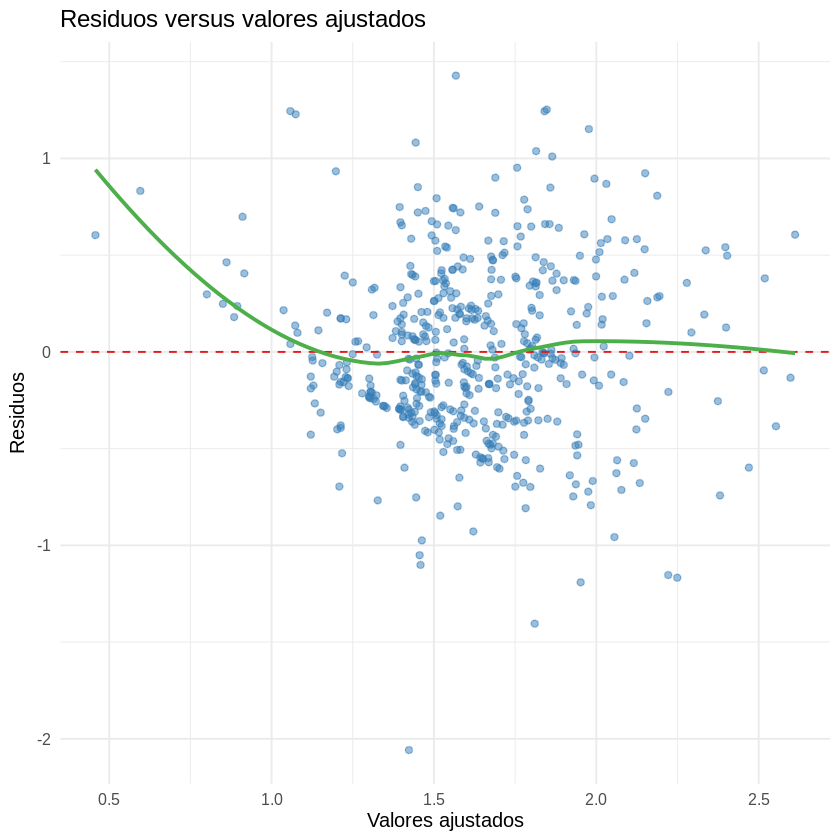

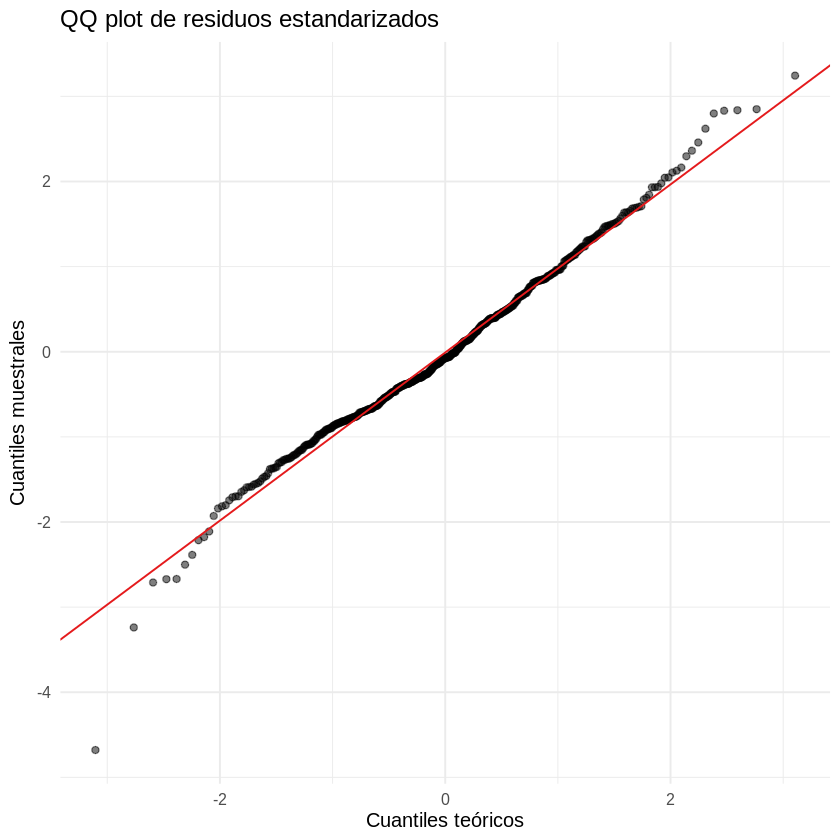

In [20]:
diagnostico <- tibble(
  ajustado = fitted(modelo_multi),
  residuo = resid(modelo_multi),
  residuo_estandarizado = rstandard(modelo_multi)
)

p_residuos <- ggplot(diagnostico, aes(x = ajustado, y = residuo)) +
  geom_point(alpha = 0.5, color = '#377eb8') +
  geom_hline(yintercept = 0, linetype = 'dashed', color = '#e41a1c') +
  geom_smooth(se = FALSE, method = 'loess', color = '#4daf4a') +
  labs(title = 'Residuos versus valores ajustados', x = 'Valores ajustados', y = 'Residuos')

p_qq <- ggplot(diagnostico, aes(sample = residuo_estandarizado)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line(color = '#e41a1c') +
  labs(title = 'QQ plot de residuos estandarizados', x = 'Cuantiles teóricos', y = 'Cuantiles muestrales')

print(p_residuos)
print(p_qq)

## 11. Predicción para perfiles hipotéticos

Finalmente, podemos usar el modelo ampliado para predecir el log-salario medio de perfiles con distinta educación, manteniendo experiencia y antigüedad constantes. El intervalo mostrado es de confianza para la media condicional, no un intervalo de predicción para una persona individual.

In [ ]:
nuevos_trabajadores <- tibble(
  educ = c(12, 16, 18),
  exper = c(10, 10, 10),
  tenure = c(5, 5, 5)
)

predicciones <- predict(modelo_multi, newdata = nuevos_trabajadores, interval = 'confidence', level = 0.95)

bind_cols(nuevos_trabajadores, as_tibble(predicciones)) %>%
  mutate(
    wage_estimado = exp(fit),
    wage_limite_inferior = exp(lwr),
    wage_limite_superior = exp(upr)
  )

## 12. Resumen del flujo

- La exploración inicial permite conocer tipos, faltantes, duplicados, rangos y distribución de las variables.
- Los gráficos univariados describen cada variable; los bivariados muestran relaciones y posibles diferencias entre grupos.
- `lm()` estima modelos lineales y `summary()` incluye tests t individuales para `H0: beta_j = 0`.
- `coeftest()` permite repetir esos tests y reemplazar los errores estándar por versiones robustas.
- `linearHypothesis()` permite probar diferencias y varias restricciones simultáneas.
- `anova()` compara modelos anidados cuando las restricciones consisten en eliminar variables.
- El ajuste y la significancia estadística deben interpretarse junto con los diagnósticos y el contexto económico; un p-value pequeño no prueba causalidad.